# Лабораторная работа № 4.2 — Краевая задача: стрельба и конечные разности

Вариант 6. 

Искомое решение известно на обоих концах отрезка. Метод стрельбы подбирает начальную производную; конечно-разностный метод решает трёхдиагональную систему.

## Исходные данные

Числа ниже соответствуют файлу input.txt этой работы.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List

rows = [[0.0], [-0.5773502691896257], [0.0, 0.5235987755982988], [0.05235987755982988]]
y0, y1, interval, h = rows[0][0], rows[1][0], rows[2], rows[3][0]
print('Краевые условия:', y0, y1, 'отрезок:', interval, 'h =', h)

Краевые условия: 0.0 -0.5773502691896257 отрезок: [0.0, 0.5235987755982988] h = 0.05235987755982988


## Метод стрельбы

Для пробной производной η решаем задачу Коши методом Рунге–Кутты. Невязку в правом конце обнуляем методом секущих.

In [2]:
def f(x, y, z):
    return 2 * (1 + math.tan(x) ** 2) * y


def exact_solution(x):
    return -math.tan(x)


def make_grid(interval, h):
    l, r = interval
    if not all(math.isfinite(v) for v in (l, r, h)) or h <= 0 or r <= l:
        raise ValueError("Expected a finite interval l < r and h > 0")
    n = round((r - l) / h)
    if n < 1 or not math.isclose(n * h, r - l, rel_tol=1e-12, abs_tol=1e-14):
        raise ValueError("The step must divide the interval into an integer number of parts")
    return [l + i * h for i in range(n)] + [r]


def runge_romberg(coarse, fine, order):
    """Оценка погрешности на мелкой сетке в общих узлах."""
    if len(fine) != 2 * len(coarse) - 1:
        raise ValueError("Expected nested grids with step ratio 2")
    return max(abs(a - fine[2*i]) for i, a in enumerate(coarse)) / (2**order - 1)


def runge_kutta_method(y0, z0, interval, h):
    x = make_grid(interval, h)
    y = [y0]
    z = [z0]
    for i in range(len(x) - 1):
        k1 = h * z[i]
        l1 = h * f(x[i], y[i], z[i])
        k2 = h * (z[i] + l1 / 2)
        l2 = h * f(x[i] + h / 2, y[i] + k1 / 2, z[i] + l1 / 2)
        k3 = h * (z[i] + l2 / 2)
        l3 = h * f(x[i] + h / 2, y[i] + k2 / 2, z[i] + l2 / 2)
        k4 = h * (z[i] + l3)
        l4 = h * f(x[i] + h, y[i] + k3, z[i] + l3)
        y.append(y[i] + (k1 + 2 * k2 + 2 * k3 + k4) / 6)
        z.append(z[i] + (l1 + 2 * l2 + 2 * l3 + l4) / 6)
    return x, y, z


def shooting_method(y0, y1, interval, h, eps=1e-12, max_iter=100):
    if not math.isfinite(eps) or eps <= 0:
        raise ValueError("eps must be finite and positive")
    n0, n1 = 0.0, -2.0
    _, previous, _ = runge_kutta_method(y0, n0, interval, h)
    residual0 = previous[-1] - y1
    for it in range(max_iter + 1):
        x, y, z = runge_kutta_method(y0, n1, interval, h)
        residual1 = y[-1] - y1
        if abs(residual1) <= eps:
            return x, y, z, n1, it
        denominator = residual1 - residual0
        if denominator == 0:
            raise ValueError("Shooting secant has zero denominator")
        n0, n1 = n1, n1 - residual1 * (n1 - n0) / denominator
        residual0 = residual1
    raise RuntimeError("Shooting method did not converge")

In [3]:
x, shooting, _, slope, steps = shooting_method(y0, y1, interval, h)
print('Начальный наклон:', slope, 'шагов секущих:', steps)
print('Невязка правого условия:', shooting[-1]-y1)

Начальный наклон: -1.0000006087604527 шагов секущих: 1
Невязка правого условия: 0.0


## Конечные разности

Вторую производную заменяем (y_(i−1)−2y_i+y_(i+1))/h² и решаем полученную трёхдиагональную систему прогонкой.

In [4]:
def finite_difference_method(y0, y1, interval, h):
    x = make_grid(interval, h)
    n = len(x) - 1
    a = [0.0] * (n + 1)
    b = [0.0] * (n + 1)
    c = [0.0] * (n + 1)
    d = [0.0] * (n + 1)
    b[0], d[0] = 1, y0
    b[n], d[n] = 1, y1
    for i in range(1, n):
        a[i] = 1 / h ** 2
        b[i] = -2 / h ** 2 - 2 * (1 + math.tan(x[i]) ** 2)
        c[i] = 1 / h ** 2

    p = [0.0] * (n + 1)
    q = [0.0] * (n + 1)
    p[0] = -c[0] / b[0]
    q[0] = d[0] / b[0]
    for i in range(1, n + 1):
        den = b[i] + a[i] * p[i - 1]
        p[i] = -c[i] / den if i < n else 0
        q[i] = (d[i] - a[i] * q[i - 1]) / den
    y = [0.0] * (n + 1)
    y[n] = q[n]
    for i in range(n - 1, -1, -1):
        y[i] = p[i] * y[i + 1] + q[i]
    return x, y

In [5]:
_, finite = finite_difference_method(y0, y1, interval, h)
for name, values in [('Стрельба', shooting), ('Разности', finite)]:
    print(name, 'максимальная ошибка:', max(abs(v-exact_solution(t)) for t,v in zip(x,values)))

Стрельба максимальная ошибка: 5.4888723288737395e-08
Разности максимальная ошибка: 4.4133949579416853e-05


## График

График показывает результат вычисления на тех же исходных данных.

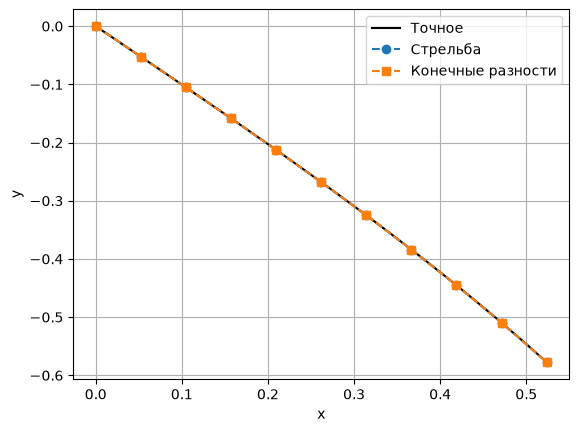

In [6]:
dense = np.linspace(*interval, 400)
plt.plot(dense, [exact_solution(t) for t in dense], color='black', label='Точное')
plt.plot(x, shooting, 'o--', label='Стрельба')
plt.plot(x, finite, 's--', label='Конечные разности')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

## Самопроверка

Сравни оба приближения с точным y=−tan(x) и проверь граничные условия.

In [7]:
assert abs(shooting[0]-y0) < 1e-12 and abs(shooting[-1]-y1) < 1e-10
assert abs(finite[0]-y0) < 1e-12 and abs(finite[-1]-y1) < 1e-10
assert max(abs(v-exact_solution(t)) for t,v in zip(x,shooting)) < 1e-5
print('Оба метода удовлетворяют граничным условиям')

Оба метода удовлетворяют граничным условиям
